In [ ]:
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv()
logging.langsmith("LangGraph")

In [ ]:
from rag.pdf import PDFRetrievalChain

# tomato_data_path = [
#     "data/tomato/토마토 백과사전.pdf",
#     "data/tomato/토마토 병해충 및 비료.pdf",
#     "data/tomato/토마토 재배법.pdf",
#     "data/tomato/토마토 농작업일정.pdf"
# ]

# strawberry_data_path = [
#     "data/strawberry/딸기 병해충 및 비료.pdf",
#     "data/strawberry/딸기 재배법.pdf",
#     "data/strawberry/딸기 농작업일정.pdf"
# ]

# tomato_data = PDFRetrievalChain(tomato_data_path).create_chain()
# strawberry_data = PDFRetrievalChain(strawberry_data_path).create_chain()

# tomato_retriever = tomato_data.retriever
# strawberry_retriever = strawberry_data.retriever


# tomato_chain = tomato_data.chain
# strawberry_chain = strawberry_data.chain

all_data_path = [
    {"path": "data/tomato/토마토 백과사전.pdf", "crop": "tomato"},
    {"path": "data/tomato/토마토 병해충 및 비료.pdf", "crop": "tomato"},
    {"path": "data/tomato/토마토 재배법.pdf", "crop": "tomato"},
    {"path": "data/tomato/토마토 농작업일정.pdf", "crop": "tomato"},
    {"path": "data/strawberry/딸기 병해충 및 비료.pdf", "crop": "strawberry"},
    {"path": "data/strawberry/딸기 재배법.pdf", "crop": "strawberry"},
    {"path": "data/strawberry/딸기 농작업일정.pdf", "crop": "strawberry"}
]

combined_data = PDFRetrievalChain(all_data_path, persist_dir="db/crop_vector", force_rebuild=False).create_chain()

combined_retriever = combined_data.retriever

combined_chain = combined_data.chain

In [ ]:
# web_search와 retriever 선택하기 (question_router)

from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_teddynote.models import get_model_name, LLMs

# 최신 LLM 모델 이름 가져오기
MODEL_NAME = get_model_name(LLMs.GPT4)


# 사용자 쿼리를 가장 관련성 높은 데이터 소스로 라우팅하는 데이터 모델
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    # 데이터 소스 선택을 위한 리터럴 타입 필드
    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )


# LLM 초기화 및 함수 호출을 통한 구조화된 출력 생성
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """An expert who communicates user questions to vector repositories or web searches.
Use only if you think the questions are related to crops such as strawberries and tomatoes covered in the "crop_vector" internal document.

Use "web_search" if it is related to something that is unlikely to exist in the internal crop data.

Select one: "crop_vector" or "web_search"""

# Routing 을 위한 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

# 프롬프트 템플릿과 구조화된 LLM 라우터를 결합하여 질문 라우터 생성
question_router = route_prompt | structured_llm_router

In [ ]:
# 질문 유효성 검사를 위한 데이터 모델
from pydantic import BaseModel, Field

class QuestionValidity(BaseModel):
    """Binary score for question validity."""
    binary_score: str = Field(
        description="Is this question based on valid, known, or verifiable concepts? Answer 'yes' or 'no'"
    )

# LLM 초기화
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_validator = llm.with_structured_output(QuestionValidity)

# 프롬프트 정의
validation_prompt = ChatPromptTemplate.from_messages([
    ("system", """
당신은 농업 분야의 전문 질문 검토자입니다.

사용자의 질문이 아래 기준을 모두 만족하는 경우에만 "yes", 그렇지 않으면 "no"라고 응답하세요.  
다른 설명 없이 반드시 "yes" 또는 "no"만 출력해야 합니다.

✅ 유효한 질문 (VALID):
- 현실 세계에 존재하는 작물, 병해, 증상 등의 개념을 기반으로 하며
- 논리적이고 과학적으로 타당한 구조를 가지고 있으며
- 계절, 기후, 지역 등 환경적으로 발생 가능한 조건에 해당하며
- 병해와 증상, 작물 등의 용어가 정확히 구분되어 있고
- 질문 문장이 문법적으로 완결되어 있으며 실제 의도를 파악할 수 있고
- 전문가 또는 문서 기반으로 실제 답변 가능한 내용이며
- 질문에 등장하는 작물과 병해가 생물학적으로 연결되어 있음 (예: 특정 병해가 해당 작물에서 발생하는 것이 실제 사례에 기반해야 함)

❌ 무효한 질문 (INVALID):
- 존재하지 않는 병해, 작물, 증상 등 허구의 개념을 포함하거나
- 증상에서 병이 발생하는 것처럼 인과관계가 잘못된 구조를 가지거나
- 겨울철 열대작물 재배 등 환경적으로 비현실적이거나
- 감정적 표현, 의인화, 혹은 농업적으로 무의미한 표현을 포함하거나
- 질문이 지나치게 포괄적이거나, 조건이 불명확하여 실제 진단/분석이 어려운 경우
- 하나의 질문에 여러 작물이나 병해가 혼재되어 판단이 불가능할 정도로 모호한 경우
- 질문에 등장하는 작물과 병해의 조합이 실제 발생 사례와 맞지 않거나, 특정 병해가 해당 작물에 발생하지 않는 경우

🧪 예시:
- "고추에 탄저병이 생겼어요. 방제법은?" → yes
- "망고가 감기에 걸렸어요." → no
- "가지마름 증상에서 역병이 나타나나요?" → no
- "겨울철에 수박 심어도 되나요?" → no
- "사과에 딸기흰가루병이 생기면 어떻게 해야 하나요?" → no
- "벼에 고추 탄저병이 생길 수 있나요?" → no
- "상추가 시들어요. 물은 줬어요. 왜 그럴까요?" → yes
- "고추, 가지, 토마토가 모두 이상해요. 왜 그러죠?" → no

출력은 반드시 "yes" 또는 "no" 중 하나로만 하세요.
"""),
    ("human", "다음 질문이 개념적으로 타당한가요?\n\n{question}")
])

# validator 체인
question_validator = validation_prompt | structured_validator

In [ ]:
# 사용자 입력과 검색된 문서간 연관성 (retrieval_grader)

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate


# 문서 평가를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM 초기화 및 함수 호출을 통한 구조화된 출력 생성
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

# 문서 검색결과 평가기 생성
retrieval_grader = grade_prompt | structured_llm_grader

In [ ]:

#web_search 관련성 평가

# 평가 결과를 담을 Pydantic 모델 정의
class GradewebDocuments(BaseModel):
    """Binary score for relevance check on web documents."""
    binary_score: str = Field(
        description="Web search document is directly relevant to the question. Answer 'yes' or 'no'."
    )

# LLM 초기화 (기존과 동일)
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_web_grader = llm.with_structured_output(GradewebDocuments)

# 보수적인 웹 관련 프롬프트
web_system_prompt = """You are a strict evaluator checking if a web document directly answers a user question.

- Only say 'yes' if the document clearly addresses or answers the question.
- Say 'no' if the document is vague, unrelated, promotional, off-topic, or does not contain direct evidence.
- Avoid over-interpreting. Be strict and conservative.
"""

# 프롬프트 템플릿 정의
web_grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", web_system_prompt),
        ("human", "Web document: \n\n {document} \n\n User question: {question}"),
    ]
)

# 웹 문서 평가용 grader 생성
web_retrieval_grader = web_grade_prompt | structured_web_grader


In [ ]:
# 사용자 질문 설정
question = "망고에서 발생하는 병해충?"

# 질문에 대한 관련 문서 검색
docs = combined_retriever.invoke(question)

# 검색된 문서의 내용 가져오기
retrieved_doc = docs[1].page_content

# 평가 결과 출력
print(retrieval_grader.invoke({"question": question, "document": retrieved_doc}))

In [ ]:
# 답변생성

from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# LangChain Hub에서 프롬프트 가져오기(RAG 프롬프트는 자유롭게 수정 가능)
prompt = hub.pull("teddynote/rag-prompt")

# LLM 초기화
llm = ChatOpenAI(model_name=MODEL_NAME, temperature=0)


# 문서 포맷팅 함수
def format_docs(docs):
    return "\n\n".join(
        [
            f'<document><content>{doc.page_content}</content><source>{doc.metadata["source"]}</source><page>{doc.metadata["page"]+1}</page></document>'
            for doc in docs
        ]
    )


# RAG 체인 생성
rag_chain = prompt | llm | StrOutputParser()


In [ ]:
# # RAG 체인에 질문을 전달하여 답변 생성
# generation = rag_chain.invoke({"context": format_docs(docs), "question": question})
# print(generation)

In [ ]:
# 할루시네이션 체크를 위한 데이터 모델 정의 (hallucination_grader)
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# 함수 호출을 통한 LLM 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# 프롬프트 설정
system = """You are a strict evaluator of hallucinations in generated answers.

Your task is to determine whether the answer is fully grounded in the provided documents.
Specifically, check that any named entities (such as diseases, crops, symptoms) are explicitly present in the sources.

If any key concept in the answer is missing from the documents, return 'no'.

Only return 'yes' if you are confident that the answer can be **directly traced** to the provided documents."""

# 프롬프트 템플릿 생성
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

# 환각 평가기 생성
hallucination_grader = hallucination_prompt | structured_llm_grader

In [ ]:
# (answer_grader)
class GradeAnswer(BaseModel):
    """Binary scoring to evaluate the appropriateness of answers to questions"""

    binary_score: str = Field(
        description="Indicate 'yes' or 'no' whether the answer solves the question"
    )


# 함수 호출을 통한 LLM 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# 프롬프트 설정
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

# 프롬프트 템플릿과 구조화된 LLM 평가기를 결합하여 답변 평가기 생성
answer_grader = answer_prompt | structured_llm_grader

In [ ]:
# 쿼리 재작성 (question_rewriter)

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

# Query Rewriter 프롬프트 정의(자유롭게 수정이 가능합니다)
system = """당신은 벡터 데이터베이스 및 웹 검색에서 더 나은 검색 결과를 얻기 위해 사용자 질문을 개선하는 전문 질문 재작성자입니다.

목표:
1. 사용자의 의도를 정확히 이해합니다.
2. 질문에서 모호하거나 불명확한 부분을 식별합니다.
3. 누락된 정보를 보완하고, 문장을 명확하게 표현하며, 질문을 더 의미 있고 정확하게 재구성합니다.

주의사항:
- 반드시 한국어로 작성하십시오.
- 재작성된 질문만 반환하십시오. 설명이나 주석을 추가하지 마십시오.
- 원래 질문과 동일한 표현을 반복하지 마십시오. 의미 있는 변화가 없는 경우에는 새로운 방식으로 재구성하십시오."""


# Query Rewriter 프롬프트 템플릿 생성
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Rewrite the following question to improve  retrieval:\n\n{question}\n\nOnly return the rewritten question.",
        ),
    ]
)

# Query Rewriter 생성
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [ ]:
question_rewriter.invoke({"question": question})

In [ ]:
# 웹 검색 도구

from langchain_teddynote.tools.tavily import TavilySearch

# 웹 검색 도구 생성
web_search_tool = TavilySearch(max_results=3)

In [ ]:
# 그래프 상태 정의

from typing import List
from typing_extensions import TypedDict, Annotated


# 그래프의 상태 정의
class GraphState(TypedDict):
    """
    그래프의 상태를 나타내는 데이터 모델

    Attributes:
        question: 질문
        generation: LLM 생성된 답변
        documents: 도큐먼트 리스트
    """

    question: Annotated[str, "User question"]
    generation: Annotated[str, "LLM generated answer"]
    documents: Annotated[List[str], "List of documents"]

In [ ]:
# 노드 정의

from langchain_core.documents import Document
from langchain.retrievers.document_compressors import CohereRerank
import os

reranker = CohereRerank(
    cohere_api_key=os.getenv("COHERE_API_KEY"),
    top_n=5,
    model="rerank-multilingual-v3.0"  # ✅ 한국어 지원 모델
)

# 문서 검색 노드
def retrieve(state):
    print("==== [RETRIEVE] ====")
    question = state["question"]

    # 문서 검색 수행
    documents = combined_retriever.invoke(question)
    reranked_documents = reranker.compress_documents(
        documents,
        query=question
    )

    return {"documents": reranked_documents}

# 노드 함수 정의
def validate_question(state):
    print("==== [VALIDATE QUESTION] ====")
    question = state["question"]
    score = question_validator.invoke({"question": question})
    if score.binary_score == "yes":
        print("==== [VALID QUESTION] ====")
        return {"question_valid": True}
    else:
        print("==== [INVALID QUESTION DETECTED] ====")
        return {"question_valid": False}

# 잘못된 질문 알림 노드
def inform_invalid_question(state):
    print("==== [INFORM INVALID QUESTION] ====")
    question = state["question"]

    message = f"""
질문이 유효하지 않다고 판단되었습니다.

입력하신 질문: "{question}"

❗ 질문에 잘못된 개념이 포함되어 있거나, 실제 존재하지 않는 정보일 가능성이 있습니다.
질문을 다시 한번 확인해 주세요.
    """.strip()

    return {
        "generation": message,
        "stop_reason": "invalid_question"
    }


# 답변 생성 노드
def generate(state):    #검색된 문서 하나하나 전부 검사 관련성 없는것은 배제
    print("==== [GENERATE] ====")
    # 질문과 문서 검색 결과 가져오기
    question = state["question"]
    documents = state["documents"]

    # RAG 답변 생성
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"generation": generation}


# 문서 관련성 평가 노드
def grade_documents(state):
    print("==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====")
    # 질문과 문서 검색 결과 가져오기
    question = state["question"]
    documents = state["documents"]

    # 각 문서에 대한 관련성 점수 계산
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            # 관련성이 있는 문서 추가
            filtered_docs.append(d)
        else:
            # 관련성이 없는 문서는 건너뛰기
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs}

# web_search 관련성 평가 노드
def grade_web_documents(state):
    print("==== [CHECK WEB DOC RELEVANCE TO QUESTION] ====")

    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    for d in documents:
        score = web_retrieval_grader.invoke({ 
            "question": question,
            "document": d.page_content
        })
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: WEB DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: WEB DOCUMENT NOT RELEVANT---")
            continue

    return {"documents": filtered_docs}

    


# 질문 재작성 노드
def transform_query(state):
    print("==== [TRANSFORM QUERY] ====")
    question = state["question"]
    better_question = question_rewriter.invoke({"question": question})
    
    if better_question.strip() == question.strip():
        print("==== [TRANSFORM QUERY RESULT: NO MEANINGFUL CHANGE] ====")
        return {"stop_reason": "no_rewrite", "question": question}
    
    return {"question": better_question}


# 웹 검색 노드
def web_search(state):
    print("==== [WEB SEARCH] ====")
    # 질문과 문서 검색 결과 가져오기
    question = state["question"]

    # 웹 검색 수행
    web_results = web_search_tool.invoke({"query": question})
    web_results_docs = [
        Document(
            page_content=web_result["content"],
            metadata={"source": web_result["url"]},
        )
        for web_result in web_results
    ]

    return {"documents": web_results_docs}

In [ ]:
# 추가 노드

# 질문 라우팅 노드
def route_question(state):
    print("==== [ROUTE QUESTION] ====")
    # 질문 가져오기
    question = state["question"]
    # 질문 라우팅
    source = question_router.invoke({"question": question})
    # 질문 라우팅 결과에 따른 노드 라우팅
    if source.datasource == "web_search":
        print("==== [ROUTE QUESTION TO WEB SEARCH] ====")
        return {"route": "web_search"}
    elif source.datasource == "vectorstore":
        print("==== [ROUTE QUESTION TO VECTORSTORE] ====")
        return {"route": "vectorstore"}
    else:
        print("==== [ROUTE QUESTION TO WEB SEARCH] ====")
        return {"route": "web_search"}




# 문서 관련성 평가 노드
def decide_to_generate(state):
    print("==== [DECISION TO GENERATE] ====")
    # 문서 검색 결과 가져오기
    filtered_documents = state["documents"]

    if not filtered_documents:
        # 모든 문서가 관련성 없는 경우 질문 재작성
        print(
            "==== [DECISION: NO RELEVANT DOCS → WEB SEARCH FALLBACK] ===="
        )
        return "transform_query"
    else:
        # 관련성 있는 문서가 있는 경우 답변 생성
        print("==== [DECISION: GENERATE] ====")
        return "generate"

def decide_to_generate2(state):
    print("==== [DECISION TO GENERATE] ====")
    # 웹 검색 결과 가져오기
    filtered_documents = state["documents"]

    if not filtered_documents:
        # 모든 문서가 관련성 없는 경우 질문 재작성
        print(
            "==== [DECISION: NO RELEVANT DOCS → transform_query] ===="
        )
        return "not relevant"
    else:
        # 관련성 있는 문서가 있는 경우 답변 생성
        print("==== [DECISION: GENERATE] ====")
        return "generate"

def hallucination_check(state):
    print("==== [CHECK HALLUCINATIONS] ====")
    # 질문과 문서 검색 결과 가져오기
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    # 환각 평가
    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Hallucination 여부 확인
    if grade == "yes":
        print("==== [DECISION: GENERATION IS GROUNDED IN DOCUMENTS] ====")

        # 답변의 관련성(Relevance) 평가
        print("==== [GRADE GENERATED ANSWER vs QUESTION] ====")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score

        # 관련성 평가 결과에 따른 처리
        if grade == "yes":
            print("==== [DECISION: GENERATED ANSWER ADDRESSES QUESTION] ====")
            return "relevant"
        else:
            print("==== [DECISION: GENERATED ANSWER DOES NOT ADDRESS QUESTION] ====")
            return "not relevant"
    else:
        print("==== [DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY] ====")
        return "hallucination"

In [ ]:
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

# 그래프 상태 초기화
workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("validate_question", validate_question)
workflow.add_node("inform_invalid_question", inform_invalid_question)
workflow.add_node("route_question", route_question)
workflow.add_node("web_search", web_search)  # 웹 검색
workflow.add_node("retrieve", retrieve)  # 문서 검색
workflow.add_node("grade_documents", grade_documents)  # 문서 평가
workflow.add_node("grade_web_documents", grade_web_documents) #web_search 평가
workflow.add_node("generate", generate)  # 답변 생성
workflow.add_node("transform_query", transform_query)  # 쿼리 변환

# 그래프 빌드
workflow.add_edge(START, "validate_question")
workflow.add_conditional_edges(
    "validate_question",
    lambda state: "valid" if state.get("question_valid", False) else "invalid",
    {
        "valid": "route_question",
        "invalid": "inform_invalid_question"
    }
)

workflow.add_edge("inform_invalid_question", END)

# workflow.add_edge("validate_question", "route_question")
workflow.add_conditional_edges(
    "route_question",
    lambda state: state["route"],  # ✅ 'route' 키를 기준으로 조건 분기
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "grade_web_documents")  # 웹 검색 후 답변 생성
workflow.add_conditional_edges(
    "grade_web_documents",
    decide_to_generate2,
    {
        "generate": "generate",
        "not relevant": "transform_query"  # 관련성 없는 경우 쿼리 재작성
    }
)
workflow.add_edge("retrieve", "grade_documents")  # 문서 검색 후 평가
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "not relevant": "transform_query"  # 관련성 없는 경우 쿼리 재작성
    }
)

workflow.add_conditional_edges(
    "transform_query",
    lambda state: "stop_reason" in state and state["stop_reason"] == "no_rewrite",
    {
        True: END,
        False: "route_question",
    }
)

workflow.add_edge("transform_query", "route_question") # 쿼리 변환 후 문서 검색
'''workflow.add_conditional_edges(
    "generate",
    hallucination_check,
    {
        "hallucination": "transform_query",  # Hallucination 발생 시 재생성
        "relevant": END,  # 답변의 관련성 여부 통과
        "not relevant": "transform_query",  # 답변의 관련성 여부 통과 실패 시 쿼리 변환
    },
)'''

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

In [ ]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app)

In [ ]:
from langchain_teddynote.messages import stream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# 질문 입력
inputs = {
    "question": "복숭아에 발생하는 병해충의 종류를 알려줘",
}

# 그래프 실행
'''stream_graph(app, inputs, config, [
    "agent", "rewrite", "generate", "inform_invalid_question"
])'''

result = app.invoke(inputs, config)
print(result.get("generation"))


transform_query 강화하기

잘못된 질문의 판별 기준 강화하기 

(개념 존재 여부, 논리적 일관성, 지역/환경 적합성, 용어 정확도 등)

# 내가 작성한 구조도로 바꿔보기

![langraph 구조도.png](<attachment:langraph 구조도.png>)
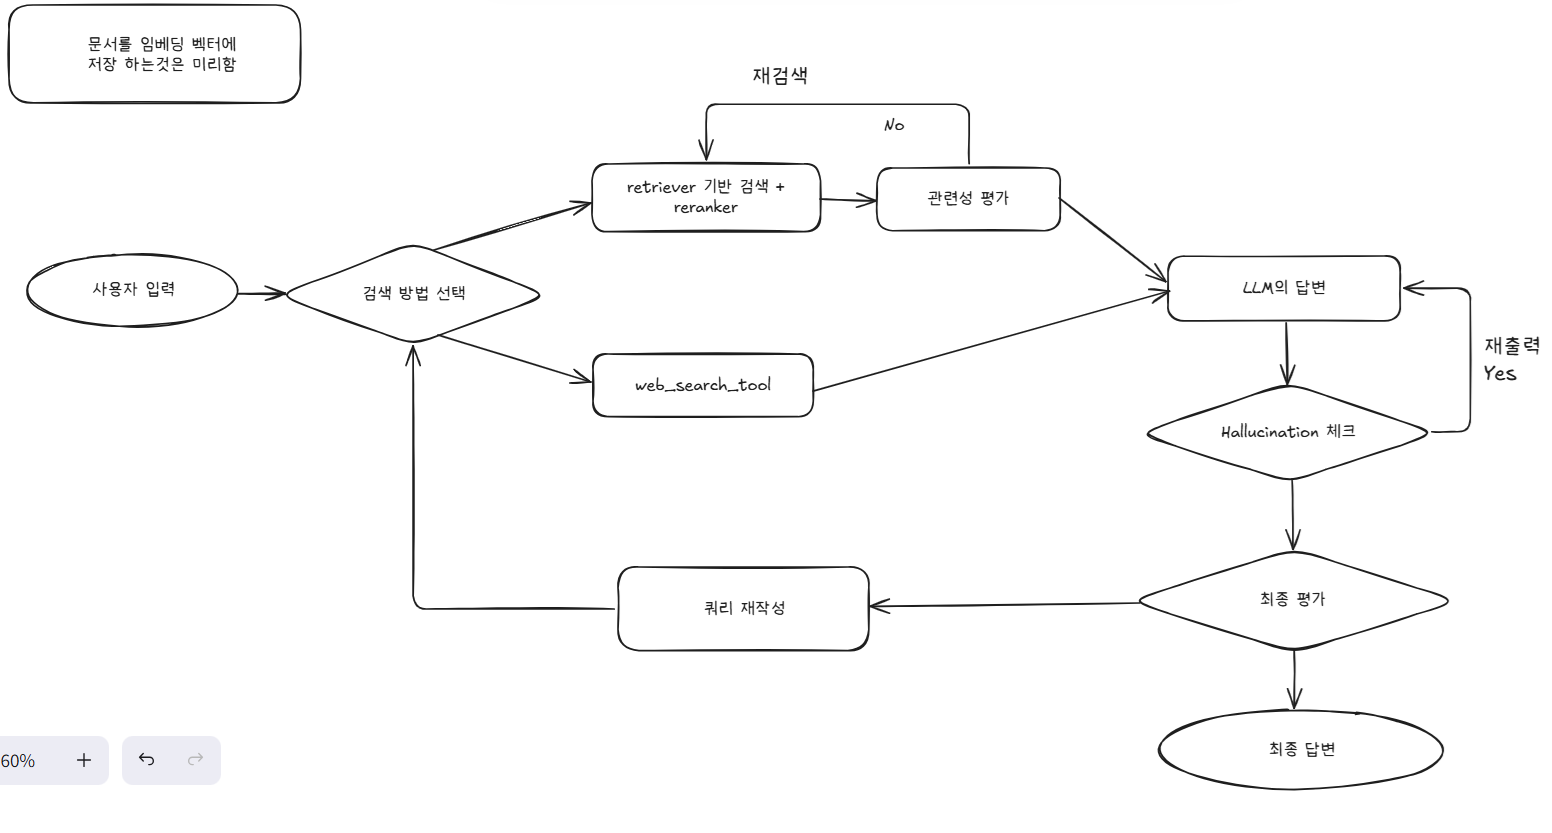